# Termination Position Curve


Plot termination probability across recall positions.


The termination position curve captures how frequently participants end recall after each output position. For every trial, we record the first point in the recall stream where responding stops and then normalize these counts across trials. Comparing these curves across datasets or conditions highlights differences in recall persistence.


In [1]:
import os

import jax.numpy as jnp
from jax import jit

from jaxcmr.analyses.termination_position import (
    plot_termination_position_curve,
    termination_position_curve,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data


In [2]:
# parameters
run_tag = "TERMINATION"
data_name = "LohnasKahana2014"
data_query = "data['list_type'] == 1"
data_path = os.path.join(find_project_root(), "data/LohnasKahana2014.h5")


## Example: Group Termination Profile


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


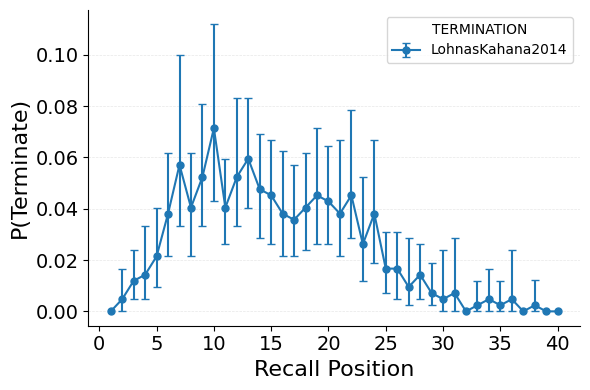

Array([0.        , 0.0047619 , 0.01190476, 0.01428572, 0.02142857,
       0.03809524, 0.05714286, 0.04047619, 0.05238095, 0.07142857],      dtype=float32)

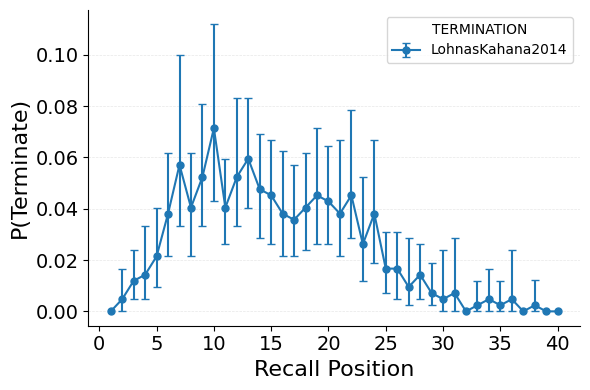

In [3]:
# Arrange / Given
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)
selected_indices = jnp.flatnonzero(trial_mask)
masked_dataset = {key: value[selected_indices] for key, value in data.items()}

# Act / When
curve_fn = jit(termination_position_curve)
group_curve = curve_fn(masked_dataset)
axis = plot_termination_position_curve(
    datasets=[data],
    trial_masks=[trial_mask],
    labels=[data_name],
    contrast_name=run_tag,
)
axis.figure.set_figwidth(6)
axis.figure.set_figheight(4)
axis.figure.tight_layout()
display(axis.figure)

# Assert / Then
group_curve[:10]
